# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setup visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
df_data = pd.read_excel('../data/processed/ethiopia_fi_unified_data_updated.xlsx', sheet_name='data')
df_impact = pd.read_excel('../data/processed/ethiopia_fi_unified_data_updated.xlsx', sheet_name='impact_links')
print("✓ Successfully loaded updated sheets from Task 1.")

✓ Successfully loaded updated sheets from Task 1.


## EXPLORATORY DATA OVERVIEWS & DATA QUALITY ASSESSMENT

In [9]:
print("=== DATASET OVERVIEW ===")
summary_type = df_data.groupby(['record_type']).size()
print(f"Counts by Record Type:\n{summary_type}\n")

=== DATASET OVERVIEW ===
Counts by Record Type:
record_type
event          11
observation    31
target          3
dtype: int64



In [10]:
print("--- Confidence Level Distribution ---")
print(df_data['confidence'].value_counts(dropna=False))

--- Confidence Level Distribution ---
confidence
high      42
medium     3
Name: count, dtype: int64


### VISUALIZATION 1: TIMELINE OVERLAY & ACCOUNT TRAJECTORY

In [16]:
df_data['year'] = pd.to_datetime(df_data['observation_date']).dt.year

(0.0, 100.0)

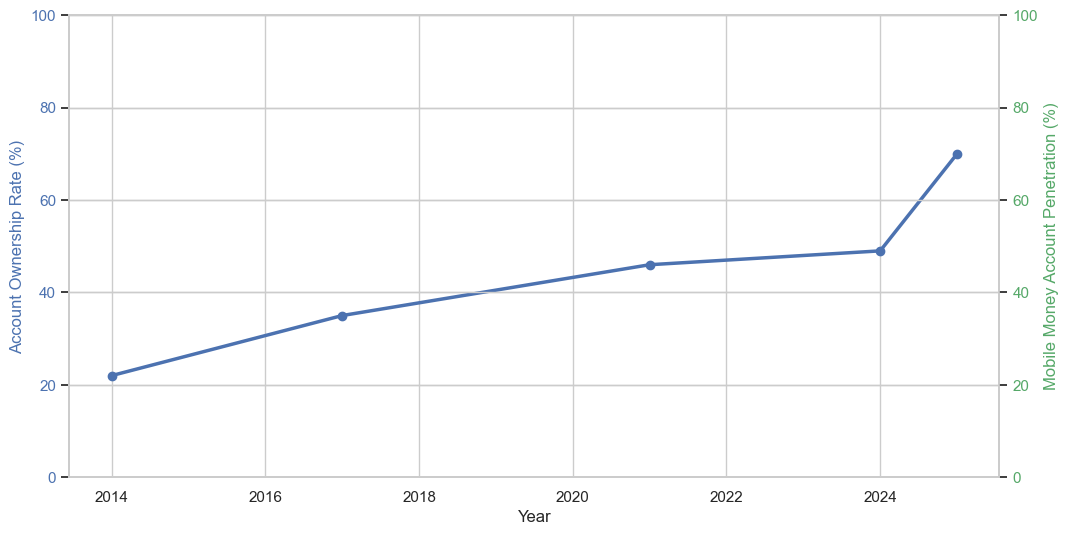

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Filter for National, All-Gender Account Ownership Track
df_acc = df_data[(df_data['indicator_code'] == 'ACC_OWNERSHIP') & (df_data['gender'] == 'all')].sort_values('year')

# Plot demand-side trajectory line
ax1.plot(df_acc['year'], df_acc['value_numeric'], marker='o', color='b', linewidth=2.5, label='Findex Account Ownership %')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Account Ownership Rate (%)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(0, 100)

# Create twin axis for supply-side Mobile Money penetration trends
ax2 = ax1.twinx()
df_mm = df_data[df_data['indicator_code'] == 'MOBILE_MONEY_ACC'].sort_values('year')
ax2.plot(df_mm['year'], df_mm['value_numeric'], marker='s', color='g', linestyle='--', linewidth=2, label='Mobile Money % (Findex)')
ax2.set_ylabel('Mobile Money Account Penetration (%)', color='g', fontsize=12)
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(0, 100)

### VISUALIZATION 2: GENDER SPLIT DEMAND HOVER

In [23]:
df_gender = df_data[(df_data['indicator_code'] == 'ACC_OWNERSHIP') & (df_data['gender'].isin(['male', 'female', 'all']))]

In [25]:
print(df_data[df_data['indicator_code'] == 'ACC_OWNERSHIP']['gender'].unique())

['all' 'male' 'female']


C:\Users\dagic\AppData\Local\Temp\ipykernel_22132\2294502530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gender, x='gender', y='value_numeric', palette='muted')


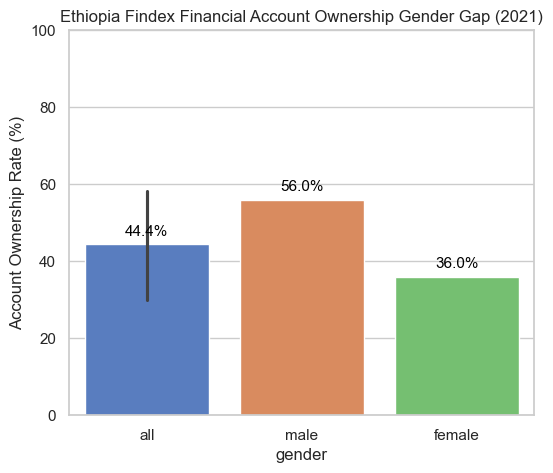

In [26]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df_gender, x='gender', y='value_numeric', palette='muted')
plt.title("Ethiopia Findex Financial Account Ownership Gender Gap (2021)")
plt.ylabel("Account Ownership Rate (%)")
plt.ylim(0, 100)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
        ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.savefig('../reports/figures/gender_gap_analysis.png', dpi=300)
plt.show()